## Interactive notebook to test GA optimisation of excitation transfer

## 1. Imports

In [80]:
from qtransfer.network.adjacency import random_adjacency
from qtransfer.network import Network, ControlSequence

from qgene.optimisation import  GeneticOptimiser
from qgene.operators import UniformCrossover, DiscreteMutation
from qgene.selection import UniformSelection
from qgene.individual import Individual

from qsim.state import DensityMatrix
import numpy as np
import random

## 2. Target

In [81]:
n=6
p=0.7
initial_node = 0
rho0 = np.zeros((n,n))
rho0[initial_node, initial_node] = 1
#rho0 = np.outer(np.array([1/(n**0.5) for i in range(n)]), np.array([1/(n**0.5) for i in range(n)]))
rho0 = DensityMatrix(rho0)
sink_locations = [5]
sink_coupling_strengths = [1]
env_damping = [0.3 for i in range(n)]

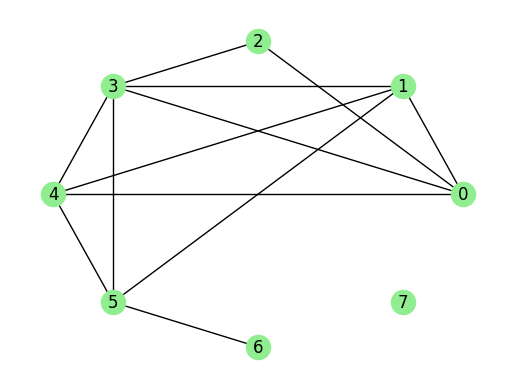

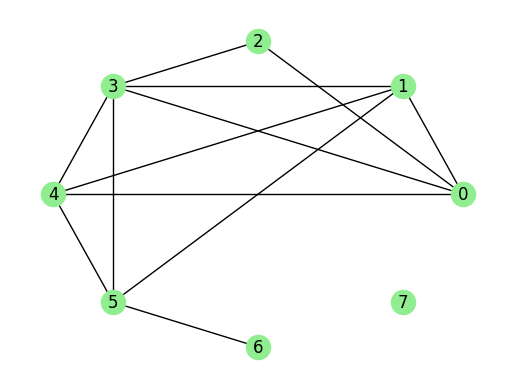

In [82]:
target_adj = random_adjacency(n, p, seed = 112)
target_network = Network(target_adj, rho0=rho0, sink_coupling_strengths=sink_coupling_strengths, sink_locations=sink_locations, local_loss_strengths=env_damping)
target_network.diagram()

In [83]:
target_network.energy_transfer

np.float64(0.6233992773914052)

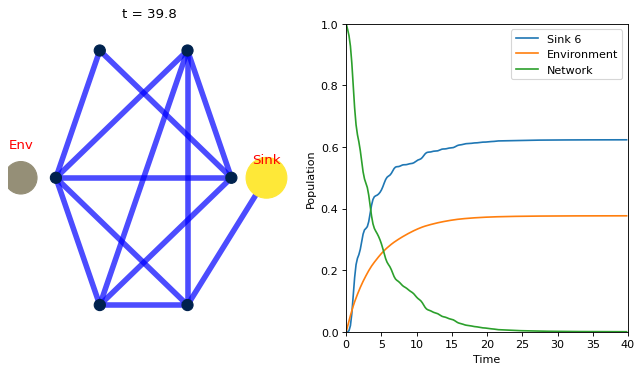

In [84]:
ts = 0.2
n_steps = 200
target_network.animateEvolutionWithConnections(ts, n_steps)

## 3. Settings

In [85]:
control_times = [0, 3]

In [86]:
control_ranges = target_network.A

In [87]:
import numpy as np

def square_lattice_mask_lower(L, periodic=False):
    N = L * L
    mask = np.zeros((N, N), dtype=bool)

    def idx(i, j):
        return i * L + j

    for i in range(L):
        for j in range(L):
            current = idx(i, j)

            neighbours = [
                (i+1, j),
                (i-1, j),
                (i, j+1),
                (i, j-1),
            ]

            for ni, nj in neighbours:
                if periodic:
                    ni %= L
                    nj %= L
                else:
                    if not (0 <= ni < L and 0 <= nj < L):
                        continue

                neighbour = idx(ni, nj)

                # only keep lower triangular part
                if current > neighbour:
                    mask[current, neighbour] = True

    return mask

In [88]:
control_mask = np.zeros((n,n))
control_mask[np.tril_indices(n, k=-1)] = 1
control_mask = (control_mask == 1)

control_mask = square_lattice_mask_lower(3)

In [89]:
vectorised_adj = target_adj[control_mask].flatten()

In [90]:
limits = [] 

for t in control_times:
    limits += [np.linspace(0, 1, 20) - x for x in vectorised_adj]

## 4. Initial Population

In [91]:
pop_size = 200

In [92]:
pop = [Individual(tuple(random.choice(lims) for lims in limits)) for i in range(pop_size)]


# 5. Optimiser

In [93]:
def score_func(pop: list[Individual]):
    for p in pop:
        if p.score is None:
            control = ControlSequence.from_individual(control_times, p, n, control_mask)
            net = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)
            p.score = net.energy_transfer# - net.control_cost

In [94]:
crossover = UniformCrossover()
mutation = DiscreteMutation(p = 0.1, vals=limits)
selection = UniformSelection(pop_fraction=0.25)

In [95]:
g = GeneticOptimiser(pop, score_func=score_func, selection_func=selection, crossover_func=crossover, mutation_func=mutation, retention=0.02, verbose=1)

In [96]:
g.optimise(early_stopping=True)

Best: 0.7811 | Mean: 0.6757 | Div: 0.2075:  38%|███▊      | 38/100 [14:05<22:58, 22.24s/it]

Early stopping


In [97]:
control = ControlSequence.from_individual(control_times, g.optimal_individual, n, control_mask)
net2 = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)

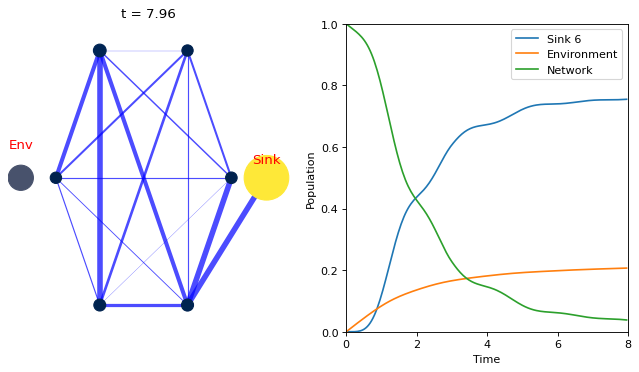

In [98]:
net2.animateEvolutionWithConnections(ts*0.2, n_steps)

In [99]:
net.animateEvolutionWithConnectionsSquare(ts*0.2, n_steps)

NameError: name 'net' is not defined

In [ ]:
net.animateEvolutionWithExcitationFlow(ts*0.2,n_steps)

NameError: name 'net' is not defined

In [ ]:
net.energy_transfer

np.float64(0.7333196214318399)

In [ ]:
net2.energy_transfer

np.float64(0.7849791756093967)

In [ ]:
net2.control_cost

np.float64(0.0)